In [1]:
import subprocess
for pkg in ['requests', 'beautifulsoup4', 'lxml']:
    subprocess.run(['pip', 'install', pkg, '--quiet'],
                   capture_output=True)
print("✅ Librerías instaladas")

import requests
from bs4 import BeautifulSoup
import pandas as pd
import os

os.chdir(r"D:\DataScience")

# === PRIMER SCRAPE — Portal datos abiertos CDMX ===
URL = "https://datos.cdmx.gob.mx/dataset?q=transito&sort=score+desc%2C+metadata_modified+desc"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 (KHTML, like Gecko) '
                  'Chrome/120.0.0.0 Safari/537.36'
}

print("=== DESCARGANDO PORTAL DATOS CDMX ===")
respuesta = requests.get(URL, headers=headers, timeout=15)

print(f"Código de respuesta: {respuesta.status_code}")
print(f"Tamaño del HTML:     {len(respuesta.text):,} caracteres")

if respuesta.status_code == 200:
    soup = BeautifulSoup(respuesta.text, 'lxml')

    # Extraer títulos de datasets
    datasets = soup.find_all('h3', class_='dataset-heading')

    print(f"\nDatasets encontrados: {len(datasets)}")
    print("\n── Datasets de tránsito disponibles ──")
    for i, ds in enumerate(datasets, 1):
        titulo = ds.get_text(strip=True)
        link   = ds.find('a')
        url_ds = f"https://datos.cdmx.gob.mx{link['href']}" if link else '—'
        print(f"  {i:>2}. {titulo}")
        print(f"      {url_ds}")
else:
    print(f"❌ Error al conectar: {respuesta.status_code}")

✅ Librerías instaladas
=== DESCARGANDO PORTAL DATOS CDMX ===
Código de respuesta: 200
Tamaño del HTML:     48,242 caracteres

Datasets encontrados: 0

── Datasets de tránsito disponibles ──


In [2]:
# === INSPECCIONAR ESTRUCTURA REAL DEL HTML ===

soup = BeautifulSoup(respuesta.text, 'lxml')

# Ver todas las clases disponibles en el HTML
print("=== PRIMEROS 3000 CARACTERES DEL HTML ===")
print(respuesta.text[:3000])

=== PRIMEROS 3000 CARACTERES DEL HTML ===
<!DOCTYPE html>
<!--[if IE 9]> <html lang="es" class="ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="es"> <!--<![endif]-->
  <head>
    <meta charset="utf-8" />
      <meta name="generator" content="ckan 2.10.0a" />
      <meta name="viewport" content="width=device-width, initial-scale=1.0">
      <meta name="author" content="Agencia Digital de Innovación Pública">
      <meta name="revisit-after" content="2 days">
      <meta Http-Equiv="Cache-Control" Content="no-cache">
      <meta Http-Equiv="Pragma" Content="no-cache">
      <meta Http-Equiv="Expires" Content="0">
      <meta Http-Equiv="Pragma-directive: no-cache">
      <meta Http-Equiv="Cache-directive: no-cache">
      <meta name="theme-color" content="#00af55">
      <meta name="description" content='Agencia Digital de Innovación Pública “Portal de Datos Abiertos de la CDMX” Disponible en https://datos.cdmx.gob.mx/'>
      <meta property="og:type" content="website">
      <meta

In [3]:
# === API CKAN — DATOS CDMX DIRECTO ===
# CKAN tiene API REST que devuelve JSON limpio

import requests
import pandas as pd
import json

# Buscar datasets de tránsito via API
API_URL = "https://datos.cdmx.gob.mx/api/3/action/package_search"

params = {
    'q':       'transito accidentes vialidad',
    'rows':    20,
    'start':   0,
}

print("=== BUSCANDO VIA API CKAN ===")
resp = requests.get(API_URL, params=params, timeout=15)
data = resp.json()

print(f"Status:           {resp.status_code}")
print(f"Datasets totales: {data['result']['count']}")
print(f"Datasets traídos: {len(data['result']['results'])}")
print()

# Mostrar datasets encontrados
print(f"{'#':<3} {'Nombre':<50} {'Recursos':<10} {'Modificado'}")
print("─" * 85)

datasets_info = []
for i, ds in enumerate(data['result']['results'], 1):
    nombre     = ds.get('title', '—')[:48]
    n_recursos = len(ds.get('resources', []))
    modificado = ds.get('metadata_modified', '—')[:10]
    id_ds      = ds.get('id', '')
    print(f"{i:<3} {nombre:<50} {n_recursos:<10} {modificado}")
    datasets_info.append({
        'id': id_ds, 'titulo': ds.get('title'),
        'recursos': n_recursos, 'modificado': modificado,
        'organizacion': ds.get('organization', {}).get('title', '—'),
    })

print()
print("¿Cuál te interesa más? Dime el número.")

=== BUSCANDO VIA API CKAN ===
Status:           200
Datasets totales: 6
Datasets traídos: 6

#   Nombre                                             Recursos   Modificado
─────────────────────────────────────────────────────────────────────────────────────
1   Infracciones al Reglamento de Tránsito de la Ciu   3          2025-11-07
2   Vialidades primarias de la Ciudad de México        3          2023-12-04
3   Infracciones al Reglamento de Tránsito de la Ciu   3          2025-11-08
4   Información vial de apoyo a la gestión del tráns   3          2023-02-15
5   Hechos de tránsito registrados por la SSC 2024 (   5          2025-05-02
6   Hechos de tránsito registrados por la SSC (serie   6          2024-03-11

¿Cuál te interesa más? Dime el número.


In [4]:
# === EXPLORAR RECURSOS DE LOS 4 DATASETS ===

ids_interes = [0, 1, 2, 4, 5]  # datasets 1,2,3,5,6

print("=== RECURSOS DISPONIBLES POR DATASET ===\n")

todos_recursos = []
for idx in ids_interes:
    ds = data['result']['results'][idx]
    print(f"{'─'*70}")
    print(f"📂 {ds['title']}")
    print(f"   Organización: {ds.get('organization',{}).get('title','—')}")
    print(f"   Modificado:   {ds.get('metadata_modified','—')[:10]}")
    print(f"   Recursos:")
    for r in ds['resources']:
        nombre = r.get('name','—')
        fmt    = r.get('format','—')
        url    = r.get('url','—')
        print(f"     [{fmt}] {nombre}")
        print(f"            {url}")
        todos_recursos.append({
            'dataset': ds['title'][:40],
            'nombre':  nombre,
            'formato': fmt,
            'url':     url,
        })
    print()

# Filtrar CSV y GeoJSON (útil para vialidades)
archivos = [r for r in todos_recursos
            if r['formato'].upper() in ['CSV','GEOJSON','JSON']]

print(f"=== ARCHIVOS DESCARGABLES: {len(archivos)} ===")
for i, r in enumerate(archivos, 1):
    print(f"  {i}. [{r['formato']:<8}] {r['dataset'][:35]}")
    print(f"           {r['nombre']}")
    print(f"           {r['url']}")
    print()

=== RECURSOS DISPONIBLES POR DATASET ===

──────────────────────────────────────────────────────────────────────
📂 Infracciones al Reglamento de Tránsito de la Ciudad de México
   Organización: Secretaría de Seguridad Ciudadana (SSC)
   Modificado:   2025-11-07
   Recursos:
     [CSV] Infracciones al Reglamento de Tránsito de la Ciudad de México, Parquímetros 1° Trimestre
            https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/5eb4208f-b9a4-4bb9-917e-7633bf06fdc9/download/1_trim_infrt_parq_2025.csv
     [CSV] Infracciones al Reglamento de Tránsito de la Ciudad de México, Parquímetros 2° Trimestre
            https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/08f33413-3e81-4c61-9ff1-9f954365d2cc/download/2_trim_infrt_parq_2025-.csv
     [CSV] Infracciones al Reglamento de Tránsito de la Ciudad de México, Parquímetros 3° Trimestre
            https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/9c

In [5]:
# === DESCARGAR DATASETS CLAVE ===
import os
import time

CARPETA = r"D:\DataScience\CDMX_Vial"
os.makedirs(CARPETA, exist_ok=True)

descargas = [
    # (nombre_local, url)
    ('hechos_transito_2024.csv',
     'https://datos.cdmx.gob.mx/dataset/e5a4b451-46c8-4912-825d-3ceb60487e68/resource/27b88c58-e741-4526-bfd0-5200fe272f8d/download/nuevo_acumulado_hechos_de_transito_2024.csv'),
    ('personas_sexo_2024.csv',
     'https://datos.cdmx.gob.mx/dataset/e5a4b451-46c8-4912-825d-3ceb60487e68/resource/273ac0c3-01f0-46e9-9000-a2d4ddb556de/download/nuevo_acumulado_ht_personas_lesionadas_o_fallecidas_por_sexo_2024.csv'),
    ('personas_edad_2024.csv',
     'https://datos.cdmx.gob.mx/dataset/e5a4b451-46c8-4912-825d-3ceb60487e68/resource/6eafd074-df59-4f9c-86f3-57e2fc5094c4/download/nuevo_acumulado_ht_personas_lesionadas_o_fallecidas_por_edad_2024.csv'),
    ('vehiculos_2024.csv',
     'https://datos.cdmx.gob.mx/dataset/e5a4b451-46c8-4912-825d-3ceb60487e68/resource/d377236d-d2b7-4a14-aa65-88dca057af3a/download/nuevo_acumulado_ht_vehiculos_incolucrados_2024.csv'),
    ('hechos_transito_2023.csv',
     'https://datos.cdmx.gob.mx/dataset/a9afdb1b-80ed-4f6c-a34a-0200211e527e/resource/0555dd20-d921-4f76-aa8c-1a0689f48bce/download/nuevo_acumulado_hechos_de_transito_2023_12.csv'),
    ('infracciones_parq_t1_2025.csv',
     'https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/5eb4208f-b9a4-4bb9-917e-7633bf06fdc9/download/1_trim_infrt_parq_2025.csv'),
    ('infracciones_parq_t2_2025.csv',
     'https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/08f33413-3e81-4c61-9ff1-9f954365d2cc/download/2_trim_infrt_parq_2025-.csv'),
    ('infracciones_parq_t3_2025.csv',
     'https://datos.cdmx.gob.mx/dataset/c4afac47-181c-4a86-bf81-5245c8a63949/resource/9c14ff84-391f-4b5f-b7e7-d6d2e7c4a792/download/3_trim_infrt_parq_2025.csv'),
    ('vialidades_primarias.json',
     'https://datos.cdmx.gob.mx/dataset/b3514d29-dedc-4006-90f3-156e0c56fb90/resource/df144488-b54a-45b8-a219-abbdadbb162f/download/mapa-de-las-vialidades-primarias-de-la-ciudad-de-mxico-.json'),
]

print("=== DESCARGANDO DATASETS ===\n")
descargados = []

for nombre, url in descargas:
    ruta = os.path.join(CARPETA, nombre)
    try:
        r = requests.get(url, headers=headers, timeout=30)
        if r.status_code == 200:
            with open(ruta, 'wb') as f:
                f.write(r.content)
            kb = len(r.content) / 1024
            print(f"  ✅ {nombre:<45} {kb:>8.1f} KB")
            descargados.append(nombre)
        else:
            print(f"  ❌ {nombre:<45} Error {r.status_code}")
    except Exception as e:
        print(f"  ❌ {nombre:<45} {str(e)[:40]}")
    time.sleep(0.5)  # respetar el servidor

print(f"\n✅ Descargados: {len(descargados)}/{len(descargas)}")
print(f"📂 Carpeta: {CARPETA}")

=== DESCARGANDO DATASETS ===

  ✅ hechos_transito_2024.csv                        6676.7 KB
  ✅ personas_sexo_2024.csv                          6713.5 KB
  ✅ personas_edad_2024.csv                          6743.2 KB
  ✅ vehiculos_2024.csv                              7307.6 KB
  ✅ hechos_transito_2023.csv                       27353.7 KB
  ✅ infracciones_parq_t1_2025.csv                   5067.6 KB
  ✅ infracciones_parq_t2_2025.csv                   5512.6 KB
  ✅ infracciones_parq_t3_2025.csv                   5617.8 KB
  ✅ vialidades_primarias.json                       5604.0 KB

✅ Descargados: 9/9
📂 Carpeta: D:\DataScience\CDMX_Vial


In [6]:
# === EXPLORAR ESTRUCTURA DE CADA DATASET ===
import pandas as pd
import os

CARPETA = r"D:\DataScience\CDMX_Vial"
os.chdir(CARPETA)

archivos_csv = [
    ('hechos_transito_2024.csv',      'Hechos tránsito 2024'),
    ('personas_sexo_2024.csv',        'Personas por sexo 2024'),
    ('personas_edad_2024.csv',        'Personas por edad 2024'),
    ('vehiculos_2024.csv',            'Vehículos 2024'),
    ('hechos_transito_2023.csv',      'Hechos tránsito 2023'),
    ('infracciones_parq_t1_2025.csv', 'Infracciones parquímetros T1'),
    ('infracciones_parq_t2_2025.csv', 'Infracciones parquímetros T2'),
    ('infracciones_parq_t3_2025.csv', 'Infracciones parquímetros T3'),
]

dataframes = {}

print("=== EXPLORACIÓN INICIAL DE DATASETS ===\n")
for archivo, nombre in archivos_csv:
    try:
        df = pd.read_csv(archivo, encoding='utf-8', low_memory=False)
    except:
        df = pd.read_csv(archivo, encoding='latin-1', low_memory=False)

    dataframes[nombre] = df
    print(f"── {nombre} ──")
    print(f"   Filas:    {len(df):,}")
    print(f"   Columnas: {list(df.columns)}")
    print(f"   Muestra:")
    print(df.head(2).to_string(max_cols=6))
    print()

# GeoJSON aparte
import json
with open('vialidades_primarias.json', encoding='utf-8') as f:
    geo = json.load(f)

print(f"── Vialidades primarias (GeoJSON) ──")
print(f"   Tipo:       {geo.get('type')}")
print(f"   Features:   {len(geo.get('features', []))}")
if geo.get('features'):
    props = geo['features'][0].get('properties', {})
    print(f"   Propiedades: {list(props.keys())}")

=== EXPLORACIÓN INICIAL DE DATASETS ===

── Hechos tránsito 2024 ──
   Filas:    30,655
   Columnas: ['fecha_evento', 'hora_evento', 'tipo_evento', 'fecha_captura', 'folio', 'latitud', 'longitud', 'punto_1', 'punto_2', 'colonia', 'alcaldia', 'zona_vial', 'sector', 'unidad_a_cargo', 'tipo_de_interseccion', 'interseccion_semaforizada', 'clasificacion_de_la_vialidad', 'sentido_de_circulacion', 'dia', 'prioridad', 'origen', 'unidad_medica_de_apoyo', 'matricula_unidad_medica', 'trasladado_lesionados', 'personas_fallecidas', 'personas_lesionadas']
   Muestra:
  fecha_evento hora_evento  tipo_evento  ... trasladado_lesionados personas_fallecidas personas_lesionadas
0   01/01/2024       08:03  ATROPELLADO  ...                    SI                   0                   1
1   01/01/2024       14:56  ATROPELLADO  ...                    NO                   0                   1

── Personas por sexo 2024 ──
   Filas:    30,655
   Columnas: ['fecha_evento', 'hora_evento', 'tipo_evento', 'fecha_ca

=== HECHOS DE TRÁNSITO CDMX 2024 ===
Total eventos:      30,655
Periodo:            2024-01-01 → 2024-12-31
Eventos fatales:    512 (1.7%)
Total fallecidos:   533
Total lesionados:   36,266
Alcaldías:          17
Tipos de evento:    6

── Top tipos de evento ──
tipo_evento
CHOQUE               18112
DERRAPADO             5866
ATROPELLADO           4822
CAIDA DE CICLISTA      761
CAIDA DE PASAJERO      611
VOLCADURA              483

── Top 5 alcaldías con más hechos ──
alcaldia
CUAUHTEMOC          4349
IZTAPALAPA          3997
GUSTAVO A MADERO    3679
MIGUEL HIDALGO      2359
BENITO JUAREZ       2250



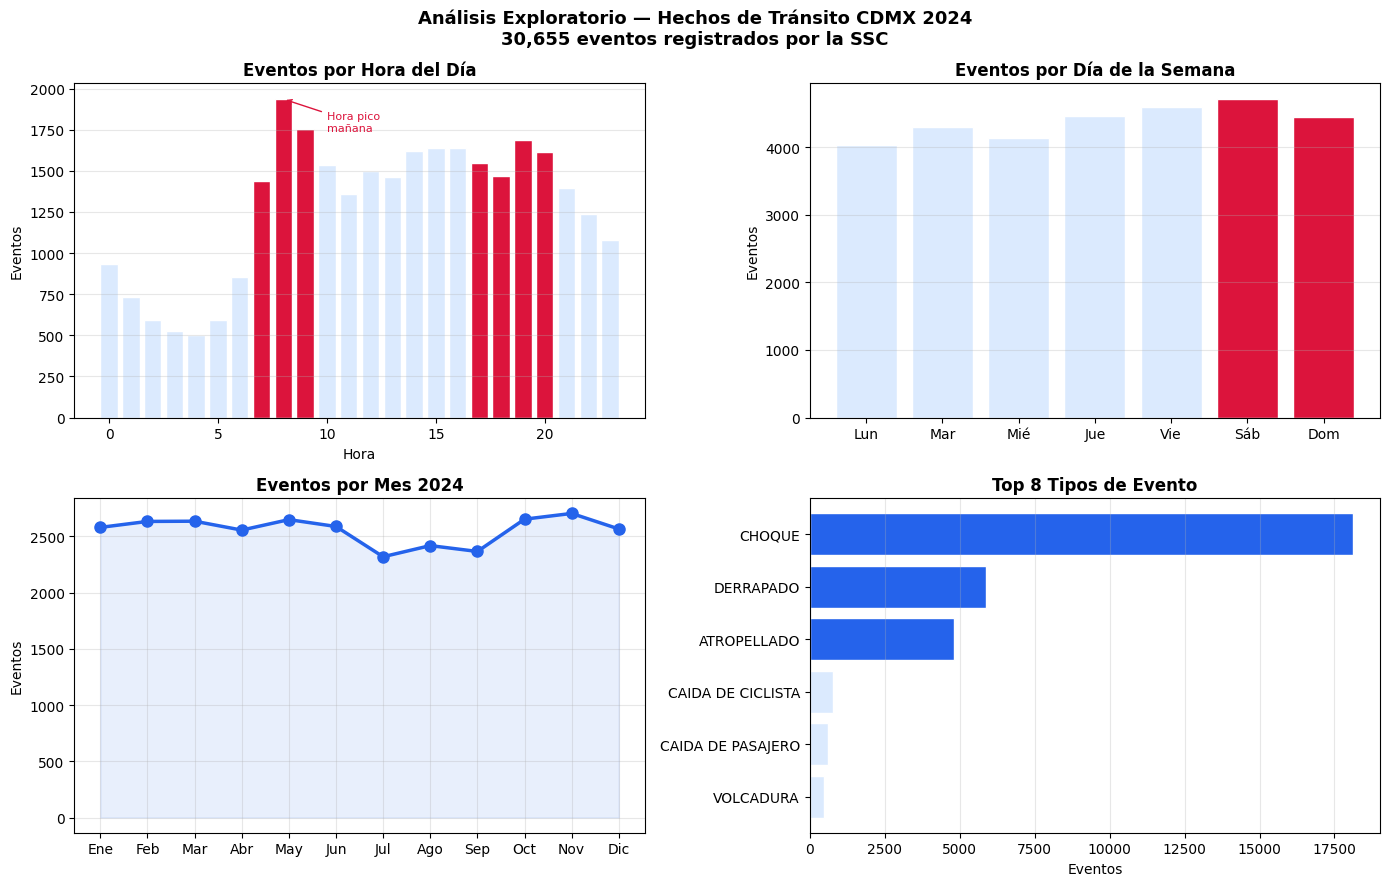

In [7]:
# === LIMPIEZA Y EDA — HECHOS DE TRÁNSITO ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

CARPETA = r"D:\DataScience\CDMX_Vial"
os.chdir(CARPETA)

# Cargar dataset principal
try:
    ht = pd.read_csv('hechos_transito_2024.csv',
                     encoding='utf-8', low_memory=False)
except:
    ht = pd.read_csv('hechos_transito_2024.csv',
                     encoding='latin-1', low_memory=False)

# ── Limpieza ──
ht['fecha_evento'] = pd.to_datetime(ht['fecha_evento'],
                                     format='%d/%m/%Y', errors='coerce')
ht['hora_num']     = ht['hora_evento'].str[:2].astype(float)
ht['mes']          = ht['fecha_evento'].dt.month
ht['mes_nombre']   = ht['fecha_evento'].dt.strftime('%b')
ht['dia_semana']   = ht['fecha_evento'].dt.day_name()
ht['es_fatal']     = ht['personas_fallecidas'] > 0

print("=== HECHOS DE TRÁNSITO CDMX 2024 ===")
print(f"Total eventos:      {len(ht):,}")
print(f"Periodo:            {ht['fecha_evento'].min().date()} → "
      f"{ht['fecha_evento'].max().date()}")
print(f"Eventos fatales:    {ht['es_fatal'].sum():,} "
      f"({ht['es_fatal'].mean()*100:.1f}%)")
print(f"Total fallecidos:   {ht['personas_fallecidas'].sum():,}")
print(f"Total lesionados:   {ht['personas_lesionadas'].sum():,}")
print(f"Alcaldías:          {ht['alcaldia'].nunique()}")
print(f"Tipos de evento:    {ht['tipo_evento'].nunique()}")
print()

# ── Top tipos de evento ──
print("── Top tipos de evento ──")
print(ht['tipo_evento'].value_counts().head(8).to_string())
print()

# ── Top alcaldías ──
print("── Top 5 alcaldías con más hechos ──")
print(ht['alcaldia'].value_counts().head(5).to_string())
print()

# ── Análisis temporal ──
por_hora = ht.groupby('hora_num').size()
por_dia  = ht.groupby('dia_semana').size().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
por_mes  = ht.groupby('mes').size()
por_tipo = ht['tipo_evento'].value_counts().head(8)

# Gráficas
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Por hora
axes[0,0].bar(por_hora.index, por_hora.values,
              color=['crimson' if (7<=h<=9 or 17<=h<=20) else '#DBEAFE'
                     for h in por_hora.index],
              edgecolor='white')
axes[0,0].set_title('Eventos por Hora del Día', fontweight='bold')
axes[0,0].set_xlabel('Hora'); axes[0,0].set_ylabel('Eventos')
axes[0,0].grid(axis='y', alpha=0.3)
axes[0,0].annotate('Hora pico\nmañana', xy=(8, por_hora.get(8,0)),
                   xytext=(10, por_hora.get(8,0)*0.9),
                   arrowprops=dict(arrowstyle='->', color='crimson'),
                   color='crimson', fontsize=8)

# Por día
dias_esp = ['Lun','Mar','Mié','Jue','Vie','Sáb','Dom']
colores_dia = ['#DBEAFE']*5 + ['crimson']*2
axes[0,1].bar(dias_esp, por_dia.values,
              color=colores_dia, edgecolor='white')
axes[0,1].set_title('Eventos por Día de la Semana', fontweight='bold')
axes[0,1].set_ylabel('Eventos'); axes[0,1].grid(axis='y', alpha=0.3)

# Por mes
meses_esp = ['Ene','Feb','Mar','Abr','May','Jun',
             'Jul','Ago','Sep','Oct','Nov','Dic']
axes[1,0].plot(range(1,13), por_mes.values, 'o-',
               color='#2563EB', linewidth=2.5, markersize=8)
axes[1,0].fill_between(range(1,13), por_mes.values,
                        alpha=0.1, color='#2563EB')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(meses_esp)
axes[1,0].set_title('Eventos por Mes 2024', fontweight='bold')
axes[1,0].set_ylabel('Eventos'); axes[1,0].grid(alpha=0.3)

# Por tipo
colores_tipo = ['#2563EB' if i < 3 else '#DBEAFE'
                for i in range(len(por_tipo))]
axes[1,1].barh(por_tipo.index[::-1], por_tipo.values[::-1],
               color=colores_tipo[::-1], edgecolor='white')
axes[1,1].set_title('Top 8 Tipos de Evento', fontweight='bold')
axes[1,1].set_xlabel('Eventos'); axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle('Análisis Exploratorio — Hechos de Tránsito CDMX 2024\n'
             f'{len(ht):,} eventos registrados por la SSC',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
print(ht['alcaldia'].value_counts().to_string())
print(f"\nValores únicos: {ht['alcaldia'].nunique()}")
print(f"Nulos: {ht['alcaldia'].isna().sum()}")

alcaldia
CUAUHTEMOC             4349
IZTAPALAPA             3997
GUSTAVO A MADERO       3679
MIGUEL HIDALGO         2359
BENITO JUAREZ          2250
VENUSTIANO CARRANZA    2248
ALVARO OBREGON         2026
COYOACAN               1959
TLALPAN                1728
AZCAPOTZALCO           1477
IZTACALCO              1430
TLAHUAC                1046
XOCHIMILCO             1018
CUAJIMALPA              461
MAGDALENA CONTRERAS     408
MILPA ALTA              219
CUAHUTEMOC                1

Valores únicos: 17
Nulos: 0


In [9]:
# Corregir typo de alcaldía
ht['alcaldia'] = ht['alcaldia'].replace('CUAHUTEMOC', 'CUAUHTEMOC')

# Verificar
print(ht['alcaldia'].value_counts().to_string())
print(f"\nAlcaldías únicas: {ht['alcaldia'].nunique()}")

alcaldia
CUAUHTEMOC             4350
IZTAPALAPA             3997
GUSTAVO A MADERO       3679
MIGUEL HIDALGO         2359
BENITO JUAREZ          2250
VENUSTIANO CARRANZA    2248
ALVARO OBREGON         2026
COYOACAN               1959
TLALPAN                1728
AZCAPOTZALCO           1477
IZTACALCO              1430
TLAHUAC                1046
XOCHIMILCO             1018
CUAJIMALPA              461
MAGDALENA CONTRERAS     408
MILPA ALTA              219

Alcaldías únicas: 16


=== HECHOS POR ALCALDÍA 2024 ===
Alcaldía                         Total  Fallec.  Lesion.  Tasa Fatal%
────────────────────────────────────────────────────────────────────
🟢 CUAUHTEMOC                     4,350       39    5,112        0.90%
🔴 IZTAPALAPA                     3,997      125    4,756        3.13%
🟡 GUSTAVO A MADERO               3,679       53    4,460        1.44%
🟡 MIGUEL HIDALGO                 2,359       30    2,703        1.27%
🟡 BENITO JUAREZ                  2,250       23    2,608        1.02%
🟡 VENUSTIANO CARRANZA            2,248       41    2,724        1.82%
🟡 ALVARO OBREGON                 2,026       35    2,390        1.73%
🟡 COYOACAN                       1,959       33    2,304        1.68%
🔴 TLALPAN                        1,728       39    2,035        2.26%
🟡 AZCAPOTZALCO                   1,477       21    1,760        1.42%
🔴 IZTACALCO                      1,430       32    1,694        2.24%
🟡 TLAHUAC                        1,046       14    1,263  

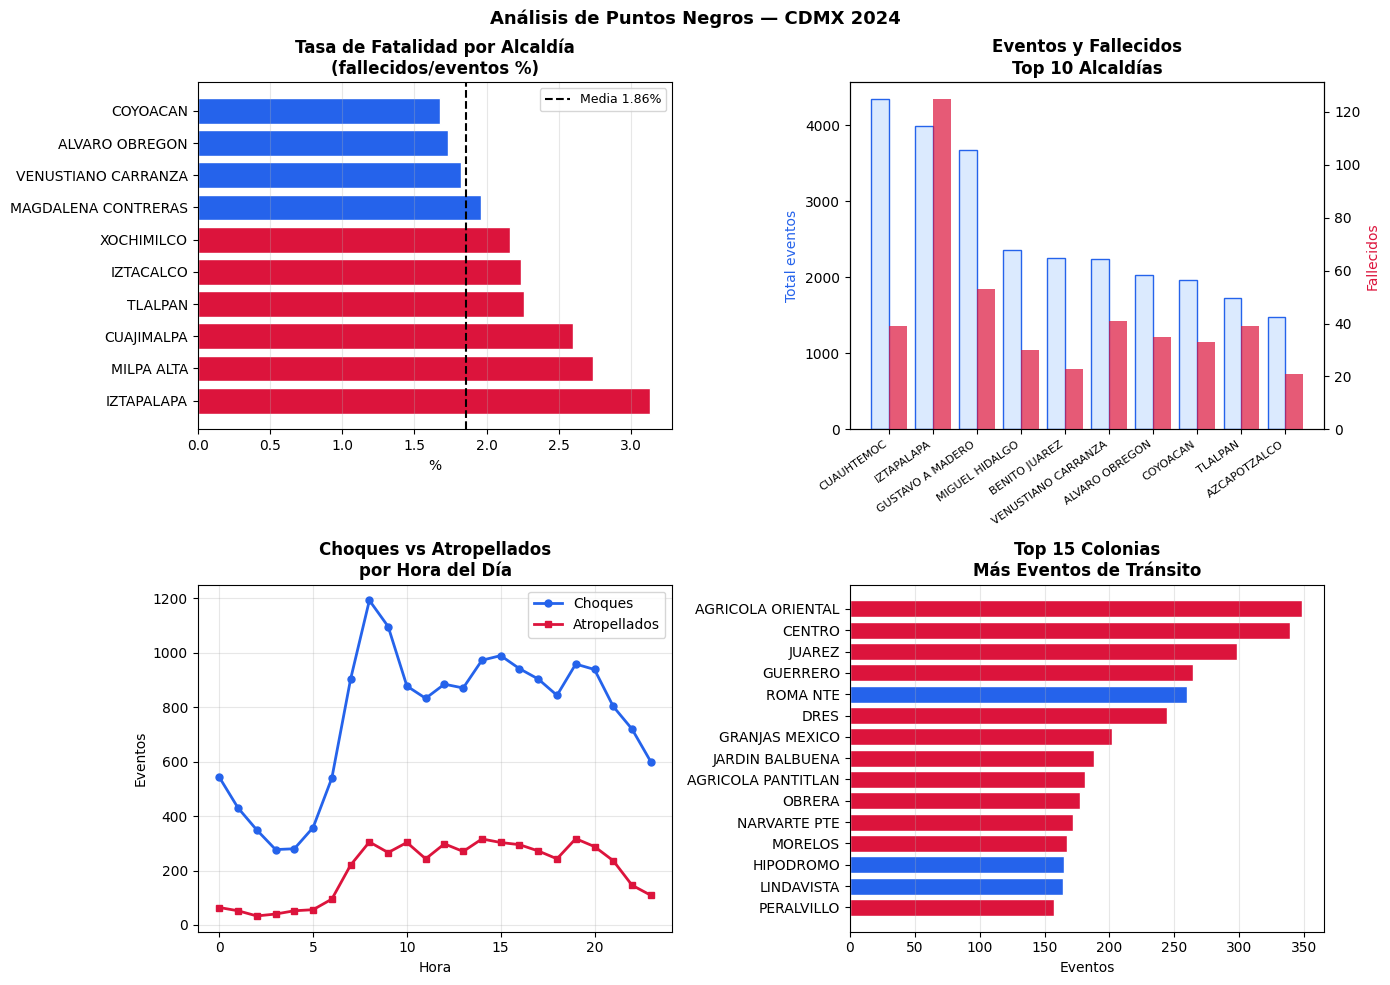

In [10]:
# === ANÁLISIS DE PUNTOS NEGROS Y ALCALDÍAS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Alcaldías completo ──
por_alcaldia = ht.groupby('alcaldia').agg(
    total        = ('folio',              'count'),
    fallecidos   = ('personas_fallecidas','sum'),
    lesionados   = ('personas_lesionadas','sum'),
    fatales      = ('es_fatal',           'sum'),
).sort_values('total', ascending=False).reset_index()

por_alcaldia['tasa_fatalidad'] = (
    por_alcaldia['fallecidos'] / por_alcaldia['total'] * 100
).round(2)
por_alcaldia['lesionados_por_evento'] = (
    por_alcaldia['lesionados'] / por_alcaldia['total']
).round(2)

print("=== HECHOS POR ALCALDÍA 2024 ===")
print(f"{'Alcaldía':<30} {'Total':>7} {'Fallec.':>8} "
      f"{'Lesion.':>8} {'Tasa Fatal%':>12}")
print("─" * 68)
for _, r in por_alcaldia.iterrows():
    flag = '🔴' if r['tasa_fatalidad'] > 2 else \
           '🟡' if r['tasa_fatalidad'] > 1 else '🟢'
    print(f"{flag} {r['alcaldia']:<28} {r['total']:>7,} "
          f"{r['fallecidos']:>8,} {r['lesionados']:>8,} "
          f"{r['tasa_fatalidad']:>11.2f}%")

# ── Análisis horario por tipo ──
print("\n=== HORA PROMEDIO POR TIPO DE EVENTO ===")
hora_tipo = ht.groupby('tipo_evento')['hora_num'].agg(
    ['mean','median','count']).round(1)
hora_tipo.columns = ['hora_media','hora_mediana','total']
hora_tipo = hora_tipo.sort_values('total', ascending=False)
print(hora_tipo.to_string())

# ── Puntos negros — colonias ──
print("\n=== TOP 15 COLONIAS MÁS PELIGROSAS ===")
por_colonia = ht.groupby(['colonia','alcaldia']).agg(
    total      = ('folio',               'count'),
    fallecidos = ('personas_fallecidas', 'sum'),
).sort_values('total', ascending=False).head(15)
print(por_colonia.to_string())

# ── Gráficas ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Tasa fatalidad por alcaldía
top_fat = por_alcaldia.nlargest(10, 'tasa_fatalidad')
colores = ['crimson' if t > 2 else '#2563EB'
           for t in top_fat['tasa_fatalidad']]
axes[0,0].barh(top_fat['alcaldia'], top_fat['tasa_fatalidad'],
               color=colores, edgecolor='white')
axes[0,0].axvline(por_alcaldia['tasa_fatalidad'].mean(),
                  color='black', linestyle='--', linewidth=1.5,
                  label=f"Media {por_alcaldia['tasa_fatalidad'].mean():.2f}%")
axes[0,0].set_title('Tasa de Fatalidad por Alcaldía\n(fallecidos/eventos %)',
                    fontweight='bold')
axes[0,0].set_xlabel('%'); axes[0,0].legend(fontsize=9)
axes[0,0].grid(axis='x', alpha=0.3)

# Total eventos + fallecidos por alcaldía (top 10)
top10_alc = por_alcaldia.head(10)
x = np.arange(len(top10_alc))
w = 0.4
ax2b = axes[0,1].twinx()
axes[0,1].bar(x, top10_alc['total'], w,
              color='#DBEAFE', edgecolor='#2563EB',
              linewidth=1, label='Total eventos')
ax2b.bar(x+w, top10_alc['fallecidos'], w,
         color='crimson', alpha=0.7, label='Fallecidos')
axes[0,1].set_xticks(x+w/2)
axes[0,1].set_xticklabels(top10_alc['alcaldia'],
                           rotation=35, ha='right', fontsize=8)
axes[0,1].set_ylabel('Total eventos', color='#2563EB')
ax2b.set_ylabel('Fallecidos', color='crimson')
axes[0,1].set_title('Eventos y Fallecidos\nTop 10 Alcaldías',
                    fontweight='bold')

# Choques por hora
choques_hora = ht[ht['tipo_evento']=='CHOQUE'].groupby('hora_num').size()
atrope_hora  = ht[ht['tipo_evento']=='ATROPELLADO'].groupby('hora_num').size()
axes[1,0].plot(choques_hora.index, choques_hora.values,
               'o-', color='#2563EB', linewidth=2,
               markersize=5, label='Choques')
axes[1,0].plot(atrope_hora.index, atrope_hora.values,
               's-', color='crimson', linewidth=2,
               markersize=5, label='Atropellados')
axes[1,0].set_title('Choques vs Atropellados\npor Hora del Día',
                    fontweight='bold')
axes[1,0].set_xlabel('Hora'); axes[1,0].set_ylabel('Eventos')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

# Top 15 colonias
top15_col = por_colonia.reset_index().head(15)
colores_c = ['crimson' if f > 0 else '#2563EB'
             for f in top15_col['fallecidos']]
axes[1,1].barh(top15_col['colonia'][::-1],
               top15_col['total'][::-1],
               color=colores_c[::-1], edgecolor='white')
axes[1,1].set_title('Top 15 Colonias\nMás Eventos de Tránsito',
                    fontweight='bold')
axes[1,1].set_xlabel('Eventos'); axes[1,1].grid(axis='x', alpha=0.3)

plt.suptitle('Análisis de Puntos Negros — CDMX 2024',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Convertir coordenadas a número
ht['latitud']  = pd.to_numeric(ht['latitud'],  errors='coerce')
ht['longitud'] = pd.to_numeric(ht['longitud'], errors='coerce')

# Ahora sí ejecuta la celda completa desde aquí
ht_geo = ht.dropna(subset=['latitud','longitud']).copy()
ht_geo = ht_geo[
    (ht_geo['latitud'].between(19.0, 19.7)) &
    (ht_geo['longitud'].between(-99.4, -98.9))
]

print(f"Eventos con coordenadas válidas: {len(ht_geo):,} de {len(ht):,}")

Eventos con coordenadas válidas: 30,652 de 30,655


In [13]:
# === MAPA DE CALOR — COORDENADAS GPS ===
import subprocess
subprocess.run(['pip', 'install', 'folium', '--quiet'], capture_output=True)

import folium
from folium.plugins import HeatMap, MarkerCluster
import pandas as pd
import numpy as np

# Limpiar coordenadas
ht_geo = ht.dropna(subset=['latitud','longitud']).copy()
ht_geo = ht_geo[
    (ht_geo['latitud'].between(19.0, 19.7)) &
    (ht_geo['longitud'].between(-99.4, -98.9))
]

print(f"Eventos con coordenadas válidas: {len(ht_geo):,} de {len(ht):,}")
print(f"Coordenadas eliminadas: {len(ht)-len(ht_geo):,}")

# ── MAPA 1: Heatmap todos los eventos ──
mapa = folium.Map(
    location=[19.42, -99.13],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# Heatmap base
heat_data = ht_geo[['latitud','longitud']].values.tolist()
HeatMap(
    heat_data,
    radius=8, blur=10,
    min_opacity=0.3,
    max_zoom=13,
    gradient={0.2:'blue', 0.4:'cyan',
              0.6:'lime', 0.8:'yellow', 1.0:'red'}
).add_to(mapa)

# Marcadores de eventos fatales
fatales = ht_geo[ht_geo['es_fatal']==True]
for _, row in fatales.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color='red', fill=True, fill_color='red',
        fill_opacity=0.8, weight=1,
        popup=folium.Popup(
            f"<b>{row['tipo_evento']}</b><br>"
            f"Fecha: {row['fecha_evento'].date()}<br>"
            f"Hora: {row['hora_evento']}<br>"
            f"Alcaldía: {row['alcaldia']}<br>"
            f"Fallecidos: {int(row['personas_fallecidas'])}<br>"
            f"Colonia: {row['colonia']}",
            max_width=200
        )
    ).add_to(mapa)

# Leyenda
leyenda = """
<div style="position:fixed; bottom:30px; left:30px; z-index:1000;
     background:rgba(0,0,0,0.8); padding:12px; border-radius:8px;
     color:white; font-family:Arial; font-size:12px;">
    <b>Hechos de Tránsito CDMX 2024</b><br>
    <span style="color:#ff4444">●</span> Evento fatal<br>
    <span style="color:#ff0">■</span> Alta concentración<br>
    <span style="color:#0ff">■</span> Media concentración<br>
    <span style="color:#00f">■</span> Baja concentración<br>
    <hr style="border-color:#555">
    Total eventos: {:,}<br>
    Eventos fatales: {:,}<br>
    Fallecidos: {:,}
</div>
""".format(len(ht_geo), int(fatales['es_fatal'].sum()),
           int(ht_geo['personas_fallecidas'].sum()))

mapa.get_root().html.add_child(folium.Element(leyenda))
mapa.save('mapa_hechos_transito_2024.html')

# ── MAPA 2: Por tipo de evento ──
mapa2 = folium.Map(
    location=[19.42, -99.13],
    zoom_start=11,
    tiles='CartoDB positron'
)

colores_tipo = {
    'CHOQUE':           'blue',
    'ATROPELLADO':      'red',
    'DERRAPADO':        'orange',
    'CAIDA DE CICLISTA':'green',
    'VOLCADURA':        'purple',
}

# Muestra aleatoria para no saturar el mapa
sample = ht_geo.sample(min(3000, len(ht_geo)), random_state=42)

for tipo, color in colores_tipo.items():
    grupo = folium.FeatureGroup(name=tipo)
    datos_tipo = sample[sample['tipo_evento']==tipo]
    for _, row in datos_tipo.iterrows():
        folium.CircleMarker(
            location=[row['latitud'], row['longitud']],
            radius=3, color=color,
            fill=True, fill_opacity=0.6, weight=0.5,
        ).add_to(grupo)
    grupo.add_to(mapa2)

folium.LayerControl().add_to(mapa2)
mapa2.save('mapa_tipos_evento_2024.html')

print("✅ Mapas generados:")
print(f"   D:\\DataScience\\CDMX_Vial\\mapa_hechos_transito_2024.html")
print(f"   D:\\DataScience\\CDMX_Vial\\mapa_tipos_evento_2024.html")
print(f"\nAbre los archivos HTML en tu navegador.")
print(f"\nEventos fatales mapeados: {len(fatales):,}")
print(f"Muestra tipo evento: {len(sample):,}")

Eventos con coordenadas válidas: 30,652 de 30,655
Coordenadas eliminadas: 3
✅ Mapas generados:
   D:\DataScience\CDMX_Vial\mapa_hechos_transito_2024.html
   D:\DataScience\CDMX_Vial\mapa_tipos_evento_2024.html

Abre los archivos HTML en tu navegador.

Eventos fatales mapeados: 512
Muestra tipo evento: 3,000


In [15]:
# === MAPAS MEJORADOS CON TÍTULOS, SIMBOLOGÍA Y ANÁLISIS ===
import folium
from folium.plugins import HeatMap, MarkerCluster
import pandas as pd
import numpy as np

# ── MAPA 1: Heatmap con título y análisis ──
mapa = folium.Map(
    location=[19.42, -99.13],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# Título superior
titulo_html = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
     z-index:1000; background:rgba(0,0,0,0.85); padding:14px 24px;
     border-radius:10px; color:white; font-family:Arial; text-align:center;
     border:1px solid #2563EB;">
    <div style="font-size:16px; font-weight:bold; color:#60A5FA;">
        🚦 Hechos de Tránsito — CDMX 2024
    </div>
    <div style="font-size:11px; color:#94A3B8; margin-top:4px;">
        Fuente: SSC · Datos Abiertos CDMX · datos.cdmx.gob.mx
    </div>
    <div style="font-size:11px; color:#94A3B8;">
        Mapa de calor — densidad de eventos registrados
    </div>
</div>
"""
mapa.get_root().html.add_child(folium.Element(titulo_html))

# Heatmap
heat_data = ht_geo[['latitud','longitud']].values.tolist()
HeatMap(
    heat_data,
    radius=9, blur=12,
    min_opacity=0.3,
    max_zoom=13,
    gradient={0.2:'blue', 0.4:'cyan',
              0.6:'lime', 0.8:'yellow', 1.0:'red'}
).add_to(mapa)

# Marcadores fatales
fatales = ht_geo[ht_geo['es_fatal']==True]
for _, row in fatales.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color='#FF0000', fill=True,
        fill_color='#FF0000', fill_opacity=0.85,
        weight=1,
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px;min-width:180px'>
            <b style='color:#EF4444'>⚠️ EVENTO FATAL</b><br><hr>
            <b>Tipo:</b> {row['tipo_evento']}<br>
            <b>Fecha:</b> {row['fecha_evento'].date()}<br>
            <b>Hora:</b> {row['hora_evento']}<br>
            <b>Alcaldía:</b> {row['alcaldia']}<br>
            <b>Colonia:</b> {row['colonia']}<br>
            <b>Fallecidos:</b> {int(row['personas_fallecidas'])}<br>
            <b>Lesionados:</b> {int(row['personas_lesionadas'])}
            </div>""",
            max_width=220
        )
    ).add_to(mapa)

# KPIs panel derecho
por_tipo_top = ht['tipo_evento'].value_counts().head(4)
filas_tipo   = ''.join([
    f"<tr><td>{t}</td><td style='text-align:right;color:#60A5FA'>{v:,}</td></tr>"
    for t, v in por_tipo_top.items()
])

por_alc_top = ht.groupby('alcaldia')['personas_fallecidas'].sum() \
                .sort_values(ascending=False).head(4)
filas_alc = ''.join([
    f"<tr><td>{a}</td><td style='text-align:right;color:#F87171'>{v}</td></tr>"
    for a, v in por_alc_top.items()
])

panel_kpi = f"""
<div style="position:fixed; top:100px; right:15px; z-index:1000;
     background:rgba(15,23,42,0.92); padding:14px;
     border-radius:10px; color:white; font-family:Arial;
     font-size:11px; border:1px solid #334155; min-width:210px;">

    <div style="font-size:13px;font-weight:bold;color:#60A5FA;
                margin-bottom:8px;">📊 KPIs 2024</div>
    <table style="width:100%;border-collapse:collapse;">
        <tr><td>Total eventos</td>
            <td style="text-align:right;color:#60A5FA">{len(ht):,}</td></tr>
        <tr><td>Eventos fatales</td>
            <td style="text-align:right;color:#F87171">{int(fatales['es_fatal'].sum()):,}</td></tr>
        <tr><td>Total fallecidos</td>
            <td style="text-align:right;color:#F87171">{int(ht['personas_fallecidas'].sum()):,}</td></tr>
        <tr><td>Total lesionados</td>
            <td style="text-align:right;color:#FCD34D">{int(ht['personas_lesionadas'].sum()):,}</td></tr>
        <tr><td>Tasa fatalidad</td>
            <td style="text-align:right;color:#F87171">
            {ht['es_fatal'].mean()*100:.1f}%</td></tr>
    </table>

    <div style="font-size:12px;font-weight:bold;color:#60A5FA;
                margin:10px 0 6px;">🚗 Por Tipo</div>
    <table style="width:100%;border-collapse:collapse;">{filas_tipo}</table>

    <div style="font-size:12px;font-weight:bold;color:#60A5FA;
                margin:10px 0 6px;">💀 Fallecidos/Alcaldía</div>
    <table style="width:100%;border-collapse:collapse;">{filas_alc}</table>
</div>
"""
mapa.get_root().html.add_child(folium.Element(panel_kpi))

# Leyenda inferior izquierda
leyenda = """
<div style="position:fixed; bottom:30px; left:15px; z-index:1000;
     background:rgba(15,23,42,0.92); padding:12px 16px;
     border-radius:10px; color:white; font-family:Arial;
     font-size:11px; border:1px solid #334155;">
    <b style="color:#60A5FA">Simbología</b><br><br>
    <span style="color:#ff4444;font-size:14px">●</span>
        Evento fatal (clic para detalle)<br>
    <div style="margin-top:6px;font-size:10px;color:#94A3B8">
    Mapa de calor:</div>
    <span style="color:#ff0000">■</span> Muy alta densidad<br>
    <span style="color:#ffff00">■</span> Alta densidad<br>
    <span style="color:#00ff00">■</span> Media densidad<br>
    <span style="color:#00ffff">■</span> Baja densidad<br>
    <span style="color:#0000ff">■</span> Mínima densidad<br>
    <hr style="border-color:#334155;margin:8px 0">
    <div style="color:#94A3B8;font-size:10px;">
    Período: Ene–Dic 2024<br>
    Alcaldías: 16 | Colonias: {}</div>
</div>
""".format(ht['colonia'].nunique())
mapa.get_root().html.add_child(folium.Element(leyenda))

# Análisis inferior centro
analisis = """
<div style="position:fixed; bottom:30px; left:50%; transform:translateX(-50%);
     z-index:1000; background:rgba(15,23,42,0.92); padding:10px 20px;
     border-radius:10px; color:white; font-family:Arial;
     font-size:11px; border:1px solid #334155; text-align:center;">
    <b style="color:#60A5FA">💡 Hallazgos clave</b> &nbsp;|&nbsp;
    Cuauhtémoc: mayor volumen pero menor fatalidad (0.90%) &nbsp;|&nbsp;
    Iztapalapa: mayor número de fallecidos (125) &nbsp;|&nbsp;
    Hora pico: 7–9am y 17–20h &nbsp;|&nbsp;
    Fin de semana: 15% más eventos
</div>
"""
mapa.get_root().html.add_child(folium.Element(analisis))

mapa.save('mapa_hechos_transito_2024.html')
print("✅ Mapa 1 guardado: mapa_hechos_transito_2024.html")

# ══════════════════════════════════════════
# MAPA 2 — Por tipo de evento con capas
# ══════════════════════════════════════════
mapa2 = folium.Map(
    location=[19.42, -99.13],
    zoom_start=11,
    tiles='CartoDB positron'
)

titulo2 = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
     z-index:1000; background:rgba(255,255,255,0.95); padding:12px 24px;
     border-radius:10px; font-family:Arial; text-align:center;
     border:2px solid #2563EB; box-shadow:0 2px 8px rgba(0,0,0,0.2);">
    <div style="font-size:15px;font-weight:bold;color:#1E293B;">
        🗺️ Distribución por Tipo de Evento — CDMX 2024
    </div>
    <div style="font-size:11px;color:#64748B;margin-top:3px;">
        Activa/desactiva capas con el control ▼ &nbsp;·&nbsp;
        SSC · Datos Abiertos CDMX
    </div>
</div>
"""
mapa2.get_root().html.add_child(folium.Element(titulo2))

config_tipos = {
    'CHOQUE':           ('#2563EB', '🚗', 18112),
    'ATROPELLADO':      ('#EF4444', '🚶', 4822),
    'DERRAPADO':        ('#D97706', '🏍️', 5866),
    'CAIDA DE CICLISTA':('#059669', '🚲', 761),
    'VOLCADURA':        ('#7C3AED', '🚛', 483),
}

sample = ht_geo.sample(min(4000, len(ht_geo)), random_state=42)

for tipo, (color, emoji, total) in config_tipos.items():
    grupo = folium.FeatureGroup(
        name=f"{emoji} {tipo} ({total:,})", show=True)
    datos_tipo = sample[sample['tipo_evento']==tipo]
    for _, row in datos_tipo.iterrows():
        folium.CircleMarker(
            location=[row['latitud'], row['longitud']],
            radius=4, color=color,
            fill=True, fill_color=color,
            fill_opacity=0.65, weight=0.8,
            popup=folium.Popup(
                f"""<div style='font-family:Arial;font-size:12px'>
                <b>{emoji} {tipo}</b><br>
                <b>Fecha:</b> {row['fecha_evento'].date()}<br>
                <b>Hora:</b> {row['hora_evento']}<br>
                <b>Alcaldía:</b> {row['alcaldia']}<br>
                <b>Colonia:</b> {row['colonia']}<br>
                <b>Vialidad:</b> {row.get('clasificacion_de_la_vialidad','—')}
                </div>""",
                max_width=200
            )
        ).add_to(grupo)
    grupo.add_to(mapa2)

folium.LayerControl(collapsed=False).add_to(mapa2)

# Simbología mapa 2
simb2 = ''.join([
    f"<div style='margin:3px 0'>"
    f"<span style='color:{color};font-size:16px'>●</span> "
    f"{emoji} {tipo} — {total:,}</div>"
    for tipo, (color, emoji, total) in config_tipos.items()
])

leyenda2 = f"""
<div style="position:fixed; bottom:30px; left:15px; z-index:1000;
     background:rgba(255,255,255,0.95); padding:14px;
     border-radius:10px; font-family:Arial; font-size:11px;
     border:1px solid #E2E8F0; box-shadow:0 2px 6px rgba(0,0,0,0.15);">
    <b style="color:#1E293B;font-size:12px">Simbología</b><br><br>
    {simb2}
    <hr style="border-color:#E2E8F0;margin:8px 0">
    <div style="color:#64748B;font-size:10px;">
    Muestra: {len(sample):,} eventos de {len(ht_geo):,}<br>
    Clic en cada punto para detalle
    </div>
</div>
"""
mapa2.get_root().html.add_child(folium.Element(leyenda2))

analisis2 = """
<div style="position:fixed; bottom:30px; left:50%; transform:translateX(-50%);
     z-index:1000; background:rgba(255,255,255,0.95); padding:10px 20px;
     border-radius:10px; font-family:Arial; font-size:11px;
     border:1px solid #E2E8F0; text-align:center;
     box-shadow:0 2px 6px rgba(0,0,0,0.15);">
    <b style="color:#1E293B">💡 Hallazgos</b> &nbsp;|&nbsp;
    Choques concentrados en ejes viales principales &nbsp;|&nbsp;
    Atropellados dispersos en toda la ciudad &nbsp;|&nbsp;
    Ciclistas: Cuauhtémoc y Benito Juárez &nbsp;|&nbsp;
    Derrapados: vialidades rápidas periféricas
</div>
"""
mapa2.get_root().html.add_child(folium.Element(analisis2))

mapa2.save('mapa_tipos_evento_2024.html')
print("✅ Mapa 2 guardado: mapa_tipos_evento_2024.html")
print(f"\n📂 Abre en tu navegador:")
print(f"   D:\\DataScience\\CDMX_Vial\\mapa_hechos_transito_2024.html")
print(f"   D:\\DataScience\\CDMX_Vial\\mapa_tipos_evento_2024.html")

✅ Mapa 1 guardado: mapa_hechos_transito_2024.html
✅ Mapa 2 guardado: mapa_tipos_evento_2024.html

📂 Abre en tu navegador:
   D:\DataScience\CDMX_Vial\mapa_hechos_transito_2024.html
   D:\DataScience\CDMX_Vial\mapa_tipos_evento_2024.html


In [16]:
# === RED VIAL PRIMARIA CDMX — GeoJSON ===
import folium
import json
import pandas as pd
import numpy as np

# Cargar GeoJSON
with open('vialidades_primarias.json', encoding='utf-8') as f:
    geo = json.load(f)

# Explorar propiedades
props_ejemplo = [f['properties'] for f in geo['features'][:5]]
print("=== PROPIEDADES DE VIALIDADES ===")
for p in props_ejemplo:
    print(p)

# Estadísticas
df_vial = pd.DataFrame([f['properties'] for f in geo['features']])
print(f"\nTotal segmentos: {len(df_vial):,}")
print(f"\n── Tipos de vía ──")
print(df_vial['TIPO_VIA'].value_counts().to_string())
print(f"\n── Carriles (distribución) ──")
print(df_vial['CARRILES'].value_counts().sort_index().to_string())
print(f"\n── Sentido de circulación ──")
print(df_vial['CIRCULA'].value_counts().to_string())
print(f"\n── Por alcaldía ──")
print(df_vial['ALCALDIA'].value_counts().to_string())

=== PROPIEDADES DE VIALIDADES ===
{'ID_VIA': 88, 'NOMBRE': 'Ruta 41', 'ID_NOM': 1, 'NOMENCLAT': 'Casa del Obrero Mundial', 'TIPO_VIA': 'Vía primaria', 'CARRILES': '2', 'NIVEL': 0, 'CIRCULA': 'Un sentido', 'ALCALDIA': 'Benito Juárez'}
{'ID_VIA': 20, 'NOMBRE': 'Eje 2 Poniente', 'ID_NOM': 2, 'NOMENCLAT': 'Casa del Obrero Mundial', 'TIPO_VIA': 'Vía primaria', 'CARRILES': '2', 'NIVEL': 0, 'CIRCULA': 'Un sentido', 'ALCALDIA': 'Benito Juárez'}
{'ID_VIA': 45, 'NOMBRE': 'Eje 10A Sur', 'ID_NOM': 1, 'NOMENCLAT': 'Avenida Copilco', 'TIPO_VIA': 'Vía primaria', 'CARRILES': '2', 'NIVEL': 0, 'CIRCULA': 'Un sentido', 'ALCALDIA': 'Coyoacán'}
{'ID_VIA': 45, 'NOMBRE': 'Eje 10A Sur', 'ID_NOM': 1, 'NOMENCLAT': 'Avenida Copilco', 'TIPO_VIA': 'Vía primaria', 'CARRILES': '2', 'NIVEL': 0, 'CIRCULA': 'Un sentido', 'ALCALDIA': 'Coyoacán'}
{'ID_VIA': 45, 'NOMBRE': 'Eje 10A Sur', 'ID_NOM': 1, 'NOMENCLAT': 'Avenida Copilco', 'TIPO_VIA': 'Vía primaria', 'CARRILES': '4', 'NIVEL': 0, 'CIRCULA': 'Un sentido', 'ALCALDIA'

In [19]:
# === MAPA RED VIAL PRIMARIA + HECHOS DE TRÁNSITO ===

mapa_vial = folium.Map(
    location=[19.42, -99.13],
    zoom_start=11,
    tiles='CartoDB dark_matter'
)

# ── Paleta por tipo de vía ──
def color_via(tipo, carriles):
    try:
        c = int(carriles)
    except:
        c = 2
    if tipo == 'Vía de acceso controlado':
        return '#F59E0B'   # naranja — vías rápidas
    if c >= 5:
        return '#60A5FA'   # azul claro — vías anchas
    if c >= 3:
        return '#2563EB'   # azul — vías medianas
    return '#475569'       # gris — vías angostas

def grosor_via(tipo, carriles):
    try:
        c = int(carriles)
    except:
        c = 2
    if tipo == 'Vía de acceso controlado': return 3.5
    if c >= 5: return 3.0
    if c >= 3: return 2.0
    return 1.2

# ── Capas de vialidades ──
capa_acceso   = folium.FeatureGroup(
    name='🟡 Vía de acceso controlado (3,558)', show=True)
capa_primaria = folium.FeatureGroup(
    name='🔵 Vía primaria (7,009)', show=True)

for feature in geo['features']:
    props = feature['properties']
    tipo  = props.get('TIPO_VIA','')
    carr  = props.get('CARRILES', 2)
    nom   = props.get('NOMBRE','—')
    nomen = props.get('NOMENCLAT','—')
    alc   = props.get('ALCALDIA','—')
    circ  = props.get('CIRCULA','—')

    color  = color_via(tipo, carr)
    weight = grosor_via(tipo, carr)

    linea = folium.GeoJson(
        feature,
        style_function=lambda x, c=color, w=weight: {
            'color':   c,
            'weight':  w,
            'opacity': 0.85,
        },
        tooltip=folium.Tooltip(
            f"<b>{nom}</b><br>"
            f"Nomenclatura: {nomen}<br>"
            f"Tipo: {tipo}<br>"
            f"Carriles: {carr} | {circ}<br>"
            f"Alcaldía: {alc}"
        )
    )

    if tipo == 'Vía de acceso controlado':
        linea.add_to(capa_acceso)
    else:
        linea.add_to(capa_primaria)

capa_primaria.add_to(mapa_vial)
capa_acceso.add_to(mapa_vial)

# ── Capa hechos fatales ──
capa_fatales = folium.FeatureGroup(
    name='🔴 Hechos fatales 2024 (512)', show=True)

fatales = ht_geo[ht_geo['es_fatal']==True]
for _, row in fatales.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=5,
        color='#EF4444', fill=True,
        fill_color='#EF4444', fill_opacity=0.9,
        weight=1,
        popup=folium.Popup(
            f"""<div style='font-family:Arial;font-size:12px;min-width:180px'>
            <b style='color:#EF4444'>⚠️ EVENTO FATAL</b><br><hr>
            <b>Tipo:</b> {row['tipo_evento']}<br>
            <b>Fecha:</b> {row['fecha_evento'].date()}<br>
            <b>Hora:</b> {row['hora_evento']}<br>
            <b>Alcaldía:</b> {row['alcaldia']}<br>
            <b>Colonia:</b> {row['colonia']}<br>
            <b>Fallecidos:</b> {int(row['personas_fallecidas'])}
            </div>""",
            max_width=220
        )
    ).add_to(capa_fatales)
capa_fatales.add_to(mapa_vial)

# ── Capa atropellados ──
capa_atrop = folium.FeatureGroup(
    name='🟠 Atropellados 2024 (4,822)', show=False)
atrope = ht_geo[ht_geo['tipo_evento']=='ATROPELLADO'].sample(
    min(1500, len(ht_geo[ht_geo['tipo_evento']=='ATROPELLADO'])),
    random_state=42)
for _, row in atrope.iterrows():
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=3,
        color='#F97316', fill=True,
        fill_color='#F97316', fill_opacity=0.7,
        weight=0.5,
    ).add_to(capa_atrop)
capa_atrop.add_to(mapa_vial)

folium.LayerControl(collapsed=False).add_to(mapa_vial)

# ── Título ──
titulo = """
<div style="position:fixed; top:10px; left:50%; transform:translateX(-50%);
     z-index:1000; background:rgba(0,0,0,0.88); padding:12px 28px;
     border-radius:10px; color:white; font-family:Arial; text-align:center;
     border:1px solid #2563EB;">
    <div style="font-size:16px;font-weight:bold;color:#60A5FA;">
        🗺️ Red Vial Primaria CDMX + Hechos de Tránsito 2024
    </div>
    <div style="font-size:11px;color:#94A3B8;margin-top:3px;">
        SEMOVI + SSC · Datos Abiertos CDMX · 10,567 segmentos viales
    </div>
</div>
"""
mapa_vial.get_root().html.add_child(folium.Element(titulo))

# ── Simbología ──
simb = """
<div style="position:fixed; bottom:30px; left:15px; z-index:1000;
     background:rgba(15,23,42,0.92); padding:14px 16px;
     border-radius:10px; color:white; font-family:Arial;
     font-size:11px; border:1px solid #334155; min-width:220px;">
    <b style="color:#60A5FA;font-size:12px">Simbología — Vialidades</b><br><br>
    <span style="color:#F59E0B">━━</span>
        Vía de acceso controlado<br>
    <span style="color:#60A5FA">━━</span>
        Vía primaria (5+ carriles)<br>
    <span style="color:#2563EB">━━</span>
        Vía primaria (3–4 carriles)<br>
    <span style="color:#475569">━━</span>
        Vía primaria (1–2 carriles)<br>
    <br>
    <b style="color:#60A5FA;font-size:12px">Hechos de Tránsito</b><br><br>
    <span style="color:#EF4444;font-size:16px">●</span>
        Evento fatal (clic = detalle)<br>
    <span style="color:#F97316;font-size:12px">●</span>
        Atropellado (capa opcional)<br>
    <hr style="border-color:#334155;margin:8px 0">
    <div style="color:#94A3B8;font-size:10px;">
        Hover sobre vialidad = datos<br>
        Período: Ene–Dic 2024
    </div>
</div>
"""
mapa_vial.get_root().html.add_child(folium.Element(simb))

# ── Análisis ──
analisis = """
<div style="position:fixed; bottom:30px; left:50%;transform:translateX(-50%);
     z-index:1000; background:rgba(15,23,42,0.92); padding:10px 20px;
     border-radius:10px; color:white; font-family:Arial;
     font-size:11px; border:1px solid #334155; text-align:center;">
    <b style="color:#60A5FA">💡 Hallazgos</b> &nbsp;|&nbsp;
    Hechos fatales concentrados en vías primarias de alta velocidad &nbsp;|&nbsp;
    Atropellados dispersos en toda la red &nbsp;|&nbsp;
    Vías de acceso controlado: menor densidad de incidentes
</div>
"""
mapa_vial.get_root().html.add_child(folium.Element(analisis))

mapa_vial.save('mapa_red_vial_cdmx.html')
print("✅ Mapa guardado: mapa_red_vial_cdmx.html")
print("📂 D:\\DataScience\\CDMX_Vial\\mapa_red_vial_cdmx.html")
print(f"\nCapas disponibles:")
print(f"  🔵 Vía primaria        — 7,009 segmentos")
print(f"  🟡 Acceso controlado   — 3,558 segmentos")
print(f"  🔴 Hechos fatales      — {len(fatales):,} eventos")
print(f"  🟠 Atropellados        — muestra 1,500")

✅ Mapa guardado: mapa_red_vial_cdmx.html
📂 D:\DataScience\CDMX_Vial\mapa_red_vial_cdmx.html

Capas disponibles:
  🔵 Vía primaria        — 7,009 segmentos
  🟡 Acceso controlado   — 3,558 segmentos
  🔴 Hechos fatales      — 512 eventos
  🟠 Atropellados        — muestra 1,500


In [18]:
df_vial['ALCALDIA_NORM'] = df_vial['ALCALDIA'].apply(
    lambda x: x.split('/')[0].strip()
)

print("── Alcaldías normalizadas ──")
print(df_vial['ALCALDIA_NORM'].value_counts().to_string())
print(f"\nTotal únicos: {df_vial['ALCALDIA_NORM'].nunique()}")

cruces = df_vial[df_vial['ALCALDIA'].str.contains('/')].shape[0]
print(f"\nSegmentos en límite entre alcaldías: {cruces}")
print("→ Se asignaron a la primera alcaldía del par")

── Alcaldías normalizadas ──
ALCALDIA_NORM
Gustavo A. Madero         1440
Miguel Hidalgo            1141
Cuauhtémoc                1111
Iztapalapa                1053
Benito Juárez              933
Venustiano Carranza        899
Álvaro Obregón             894
Coyoacán                   811
Iztacalco                  585
Tlalpan                    559
Azcapotzalco               547
Xochimilco                 191
Cuajimalpa de Morelos      139
La Magdalena Contreras     126
Tláhuac                    117
Milpa Alta                  21

Total únicos: 16

Segmentos en límite entre alcaldías: 54
→ Se asignaron a la primera alcaldía del par


In [20]:
# === BUSCAR DATOS DE PAVIMENTO CDMX ===
import requests

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
                  'AppleWebKit/537.36 Chrome/120.0.0.0 Safari/537.36'
}

# Búsqueda 1 — Portal datos abiertos CDMX
API_URL = "https://datos.cdmx.gob.mx/api/3/action/package_search"

terminos = ['pavimento', 'bacheo', 'mantenimiento vial',
            'obras viales', 'infraestructura vial']

print("=== BÚSQUEDA EN PORTAL DATOS ABIERTOS CDMX ===\n")

todos = []
for term in terminos:
    resp = requests.get(API_URL,
                        params={'q': term, 'rows': 10},
                        headers=headers, timeout=15)
    if resp.status_code == 200:
        results = resp.json()['result']['results']
        print(f"── '{term}' → {len(results)} datasets ──")
        for ds in results:
            titulo = ds.get('title','—')
            mod    = ds.get('metadata_modified','—')[:10]
            org    = ds.get('organization',{}).get('title','—')
            print(f"   📂 {titulo}")
            print(f"      {org} · {mod}")
            todos.append({'termino':term, 'titulo':titulo,
                          'org':org, 'mod':mod,
                          'id':ds.get('id')})
        print()

print(f"Total resultados: {len(todos)}")

=== BÚSQUEDA EN PORTAL DATOS ABIERTOS CDMX ===

── 'pavimento' → 0 datasets ──

── 'bacheo' → 1 datasets ──
   📂 Solicitudes *0311
      Agencia Digital de Innovación Pública (ADIP) · 2024-04-01

── 'mantenimiento vial' → 1 datasets ──
   📂 Infraestructura vial ciclista
      Secretaría de Movilidad (SEMOVI) · 2025-03-31

── 'obras viales' → 1 datasets ──
   📂 Ejes viales regionales
      Instituto de Planeación Democrática y Prospectiva · 2023-02-15

── 'infraestructura vial' → 2 datasets ──
   📂 Infraestructura vial ciclista
      Secretaría de Movilidad (SEMOVI) · 2025-03-31
   📂 Ejes viales regionales
      Instituto de Planeación Democrática y Prospectiva · 2023-02-15

Total resultados: 5


In [21]:
# === BUSCAR Y DESCARGAR: BACHEO + EJES VIALES REGIONALES ===

print("=== BUSCANDO DATASETS ===\n")

# ── 1. Solicitudes 0311 (Bacheo) ──
resp_bacheo = requests.get(
    "https://datos.cdmx.gob.mx/api/3/action/package_search",
    params={'q': 'solicitudes 0311', 'rows': 5},
    headers=headers, timeout=15)

print("── Bacheo / Solicitudes 0311 ──")
for ds in resp_bacheo.json()['result']['results']:
    print(f"  📂 {ds.get('title')}")
    print(f"     ID: {ds.get('id')}")
    for r in ds.get('resources', []):
        print(f"     [{r.get('format','—')}] {r.get('name','—')}")
        print(f"            {r.get('url','—')}")
    print()

# ── 2. Ejes viales regionales ──
resp_ejes = requests.get(
    "https://datos.cdmx.gob.mx/api/3/action/package_search",
    params={'q': 'ejes viales regionales planeación', 'rows': 5},
    headers=headers, timeout=15)

print("── Ejes viales regionales ──")
for ds in resp_ejes.json()['result']['results']:
    print(f"  📂 {ds.get('title')}")
    print(f"     ID: {ds.get('id')}")
    for r in ds.get('resources', []):
        print(f"     [{r.get('format','—')}] {r.get('name','—')}")
        print(f"            {r.get('url','—')}")
    print()

=== BUSCANDO DATASETS ===

── Bacheo / Solicitudes 0311 ──
  📂 Solicitudes *0311
     ID: 529aac27-d1c1-426f-8c45-fd76fba43bf4
     [CSV] Solicitudes *0311 (2024)
            https://datos.cdmx.gob.mx/dataset/529aac27-d1c1-426f-8c45-fd76fba43bf4/resource/44913088-806d-4f80-acca-1409a8225e9c/download/locatel0311-2024.csv
     [CSV] Solicitudes *0311 (2023)
            https://datos.cdmx.gob.mx/dataset/529aac27-d1c1-426f-8c45-fd76fba43bf4/resource/1ece1ddf-3e82-44f4-9435-486b1b9167f5/download/locatel0311-2023.csv
     [CSV] Solicitudes *0311 (2022)
            https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2022.csv
     [CSV] Solicitudes *0311 (2021)
            https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2021.csv
     [CSV] Solicitudes *0311 (2020)
            https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2020.csv
     [CSV] Solicitudes *0311 (2019)
            https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2019.csv

── Ejes viales regionales ──
  📂 Ejes viales regio

In [22]:
# === DESCARGAR BACHEO + EJES VIALES ===
import os
import time

CARPETA = r"D:\DataScience\CDMX_Vial"
os.makedirs(CARPETA, exist_ok=True)

descargas = [
    ('bacheo_2024.csv',
     'https://datos.cdmx.gob.mx/dataset/529aac27-d1c1-426f-8c45-fd76fba43bf4/resource/44913088-806d-4f80-acca-1409a8225e9c/download/locatel0311-2024.csv'),
    ('bacheo_2023.csv',
     'https://datos.cdmx.gob.mx/dataset/529aac27-d1c1-426f-8c45-fd76fba43bf4/resource/1ece1ddf-3e82-44f4-9435-486b1b9167f5/download/locatel0311-2023.csv'),
    ('bacheo_2022.csv',
     'https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2022.csv'),
    ('bacheo_2021.csv',
     'https://archivo.datos.cdmx.gob.mx/suac/locatel0311-2021.csv'),
    ('ejes_viales.json',
     'https://datos.cdmx.gob.mx/dataset/41c28154-9ed6-4ba8-8946-76fe25d63893/resource/877f1129-5c04-41aa-a2e0-2f51fe718cc2/download/ejes-viales-regionales.json'),
    ('ejes_viales_diccionario.csv',
     'https://datos.cdmx.gob.mx/dataset/41c28154-9ed6-4ba8-8946-76fe25d63893/resource/a40d078c-8e09-407d-b2b6-2153e87a003d/download/diccionario_datos_ejes.csv'),
]

print("=== DESCARGANDO DATASETS ===\n")
descargados = []

for nombre, url in descargas:
    ruta = os.path.join(CARPETA, nombre)
    try:
        r = requests.get(url, headers=headers, timeout=30)
        if r.status_code == 200:
            with open(ruta, 'wb') as f:
                f.write(r.content)
            kb = len(r.content) / 1024
            print(f"  ✅ {nombre:<40} {kb:>8.1f} KB")
            descargados.append(nombre)
        else:
            print(f"  ❌ {nombre:<40} Error {r.status_code}")
    except Exception as e:
        print(f"  ❌ {nombre:<40} {str(e)[:50]}")
    time.sleep(0.5)

print(f"\n✅ Descargados: {len(descargados)}/{len(descargas)}")

# ── Explorar estructura ──
print("\n=== ESTRUCTURA DE ARCHIVOS ===\n")

for archivo in ['bacheo_2024.csv', 'bacheo_2023.csv']:
    try:
        df = pd.read_csv(os.path.join(CARPETA, archivo),
                         encoding='utf-8', low_memory=False)
    except:
        df = pd.read_csv(os.path.join(CARPETA, archivo),
                         encoding='latin-1', low_memory=False)
    print(f"── {archivo} ──")
    print(f"   Filas:    {len(df):,}")
    print(f"   Columnas: {list(df.columns)}")
    print(df.head(2).to_string(max_cols=6))
    print()

# Ejes viales
import json
with open(os.path.join(CARPETA, 'ejes_viales.json'), encoding='utf-8') as f:
    ejes = json.load(f)
print(f"── ejes_viales.json ──")
print(f"   Features: {len(ejes.get('features',[]))}")
if ejes.get('features'):
    print(f"   Propiedades: {list(ejes['features'][0]['properties'].keys())}")

=== DESCARGANDO DATASETS ===

  ✅ bacheo_2024.csv                           16902.4 KB
  ✅ bacheo_2023.csv                           82934.2 KB
  ✅ bacheo_2022.csv                           69457.0 KB
  ✅ bacheo_2021.csv                           82780.1 KB
  ✅ ejes_viales.json                            342.9 KB
  ✅ ejes_viales_diccionario.csv                   1.5 KB

✅ Descargados: 6/6

=== ESTRUCTURA DE ARCHIVOS ===

── bacheo_2024.csv ──
   Filas:    113,147
   Columnas: ['id_folio', 'fecha_solicitud', 'hora_solicitud', 'tipo_de_entrada', 'tema_solicitud', 'sexo', 'edad', 'colonia_solicitud', 'alcaldia_solicitud', 'codigo_postal_solicitud', 'estatus', 'fecha_concluido', 'alcaldia_catalogo', 'colonia_catalogo', 'longitud', 'latitud']
   id_folio fecha_solicitud hora_solicitud  ... colonia_catalogo longitud latitud
0   2399150      2024-02-02       01:32:03  ...              NaN      NaN     NaN
1   2399543      2024-02-02       09:37:42  ...              NaN      NaN     NaN

── ba

In [23]:
# === CARGAR BACHEO 2021-2024 COMPLETO ===
import pandas as pd
import os

CARPETA = r"D:\DataScience\CDMX_Vial"

archivos_bacheo = {
    2021: 'bacheo_2021.csv',
    2022: 'bacheo_2022.csv',
    2023: 'bacheo_2023.csv',
    2024: 'bacheo_2024.csv',
}

dfs = []
print("=== CARGANDO BACHEO 2021-2024 ===\n")

for anio, archivo in archivos_bacheo.items():
    ruta = os.path.join(CARPETA, archivo)
    try:
        df = pd.read_csv(ruta, encoding='utf-8', low_memory=False)
    except:
        df = pd.read_csv(ruta, encoding='latin-1', low_memory=False)
    df['anio'] = anio
    dfs.append(df)
    print(f"  ✅ {anio}: {len(df):,} solicitudes")

# Unir todo
bacheo = pd.concat(dfs, ignore_index=True)

print(f"\n  TOTAL: {len(bacheo):,} solicitudes (2021-2024)")
print(f"\n── Columnas ──")
print(list(bacheo.columns))

# Limpieza básica
bacheo['fecha_solicitud'] = pd.to_datetime(
    bacheo['fecha_solicitud'], errors='coerce')
bacheo['mes']  = bacheo['fecha_solicitud'].dt.month
bacheo['anio'] = bacheo['fecha_solicitud'].dt.year

print(f"\n── Periodo real ──")
print(f"  Desde: {bacheo['fecha_solicitud'].min()}")
print(f"  Hasta: {bacheo['fecha_solicitud'].max()}")

print(f"\n── Temas de solicitud ──")
print(bacheo['tema_solicitud'].value_counts().head(20).to_string())

print(f"\n── Estatus ──")
print(bacheo['estatus'].value_counts().to_string())

print(f"\n── Solicitudes por año ──")
print(bacheo.groupby('anio').size().to_string())

=== CARGANDO BACHEO 2021-2024 ===

  ✅ 2021: 561,313 solicitudes
  ✅ 2022: 500,940 solicitudes
  ✅ 2023: 569,362 solicitudes
  ✅ 2024: 113,147 solicitudes

  TOTAL: 1,744,762 solicitudes (2021-2024)

── Columnas ──
['id_folio', 'fecha_solicitud', 'hora_solicitud', 'tipo_de_entrada', 'tema_solicitud', 'sexo', 'edad', 'estatus', 'fecha_concluido', 'alcaldia', 'colonia_datos', '0311_colonia_registro', 'codigo_postal_solicitud', 'latitud', 'longitud', 'anio', 'colonia_solicitud', 'alcaldia_solicitud', 'alcaldia_catalogo', 'colonia_catalogo']

── Periodo real ──
  Desde: 2021-01-01 00:00:00
  Hasta: 2024-02-29 00:00:00

── Temas de solicitud ──
tema_solicitud
OTRO                                        303074
ALUMBRADO                                   180222
FALTA DE AGUA                               168095
PODA / RETIRO ARBOL                         166772
BACHEO                                       75310
MANTENIMIENTO VÍA PÚBLICA                    74842
FUGA DE AGUA                   

=== MANTENIMIENTO VIAL CDMX 2021-2024 ===
Total solicitudes viales: 231,246
% del total:              13.3%

── Por tema ──
tema_solicitud
BACHEO                                      75310
MANTENIMIENTO VÍA PÚBLICA                   74842
MANTENIMIENTO DE COLADERA / ALCANTARILLA    44700
MANTENIMIENTO DRENAJE                       19141
PAVIMENTACION                               17253

── Por año ──
anio
2021    64644
2022    76528
2023    81149
2024     8925

── Por estatus ──
estatus
CERRADO                  105474
ATENDIDO                  53148
TURNADO                   49524
AUTORIDAD RESPONSABLE     22988
RECIBIDO                    107
CANCELADO                     5

Tasa de atención: 68.6%

── Top alcaldías con más solicitudes viales ──
Alcaldía                               Total  Atendidos    Tasa%
─────────────────────────────────────────────────────────────────
🟡 GUSTAVO A. MADERO                   15,286     10,746    70.3%
🟡 CUAUHTEMOC                          14,801   

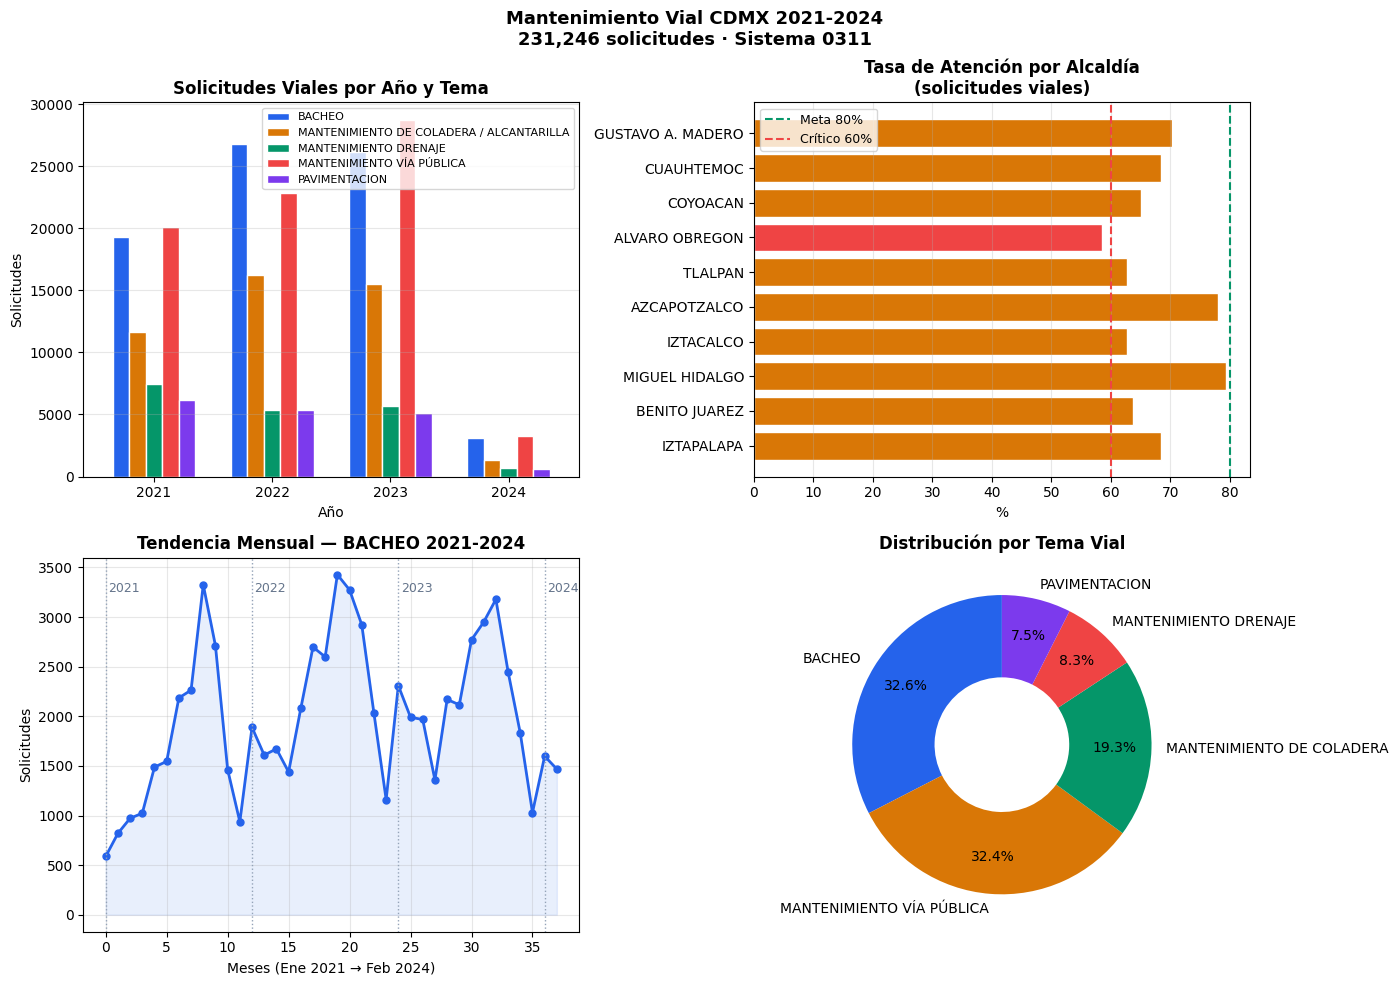

In [24]:
# === ANÁLISIS MANTENIMIENTO VIAL 2021-2024 ===
import matplotlib.pyplot as plt
import numpy as np

# Filtrar temas viales
temas_viales = [
    'BACHEO',
    'MANTENIMIENTO VÍA PÚBLICA',
    'PAVIMENTACION',
    'MANTENIMIENTO DRENAJE',
    'MANTENIMIENTO DE COLADERA / ALCANTARILLA',
]

vial = bacheo[bacheo['tema_solicitud'].isin(temas_viales)].copy()

# Normalizar columna alcaldía
vial['alc'] = vial['alcaldia'].fillna(
              vial['alcaldia_solicitud']).fillna(
              vial['alcaldia_catalogo'])
vial['alc'] = vial['alc'].str.upper().str.strip()

print("=== MANTENIMIENTO VIAL CDMX 2021-2024 ===")
print(f"Total solicitudes viales: {len(vial):,}")
print(f"% del total:              {len(vial)/len(bacheo)*100:.1f}%")
print(f"\n── Por tema ──")
print(vial['tema_solicitud'].value_counts().to_string())
print(f"\n── Por año ──")
print(vial.groupby('anio').size().to_string())
print(f"\n── Por estatus ──")
print(vial['estatus'].value_counts().to_string())

# Tasa de atención
cerrados = vial['estatus'].isin(['CERRADO','ATENDIDO']).sum()
print(f"\nTasa de atención: {cerrados/len(vial)*100:.1f}%")

# ── Análisis por alcaldía ──
por_alc = vial.groupby('alc').agg(
    total      = ('id_folio', 'count'),
    atendidos  = ('estatus', lambda x: x.isin(['CERRADO','ATENDIDO']).sum()),
).reset_index()
por_alc['tasa_atencion'] = por_alc['atendidos'] / por_alc['total'] * 100
por_alc = por_alc[por_alc['total'] > 100].sort_values('total', ascending=False)

print(f"\n── Top alcaldías con más solicitudes viales ──")
print(f"{'Alcaldía':<35} {'Total':>8} {'Atendidos':>10} {'Tasa%':>8}")
print("─"*65)
for _, r in por_alc.head(16).iterrows():
    flag = '🔴' if r['tasa_atencion'] < 60 else \
           '🟡' if r['tasa_atencion'] < 80 else '🟢'
    print(f"{flag} {r['alc']:<33} {r['total']:>8,} "
          f"{r['atendidos']:>10,} {r['tasa_atencion']:>7.1f}%")

# ── Tendencia mensual por tema ──
vial['anio_mes'] = vial['fecha_solicitud'].dt.to_period('M')
tend_tema = vial.groupby(['anio_mes','tema_solicitud']).size().unstack(fill_value=0)

# ── Gráficas ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Solicitudes por año y tema
pivot_anio = vial.groupby(['anio','tema_solicitud']).size().unstack(fill_value=0)
pivot_anio.plot(kind='bar', ax=axes[0,0],
                color=['#2563EB','#D97706','#059669','#EF4444','#7C3AED'],
                width=0.7, edgecolor='white')
axes[0,0].set_title('Solicitudes Viales por Año y Tema',
                    fontweight='bold')
axes[0,0].set_xlabel('Año')
axes[0,0].set_ylabel('Solicitudes')
axes[0,0].legend(fontsize=8, loc='upper right')
axes[0,0].tick_params(axis='x', rotation=0)
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Tasa de atención por alcaldía
top10_alc = por_alc.head(10)
colores_ta = ['#059669' if t >= 80 else
              '#D97706' if t >= 60 else '#EF4444'
              for t in top10_alc['tasa_atencion']]
axes[0,1].barh(top10_alc['alc'][::-1],
               top10_alc['tasa_atencion'][::-1],
               color=colores_ta[::-1], edgecolor='white')
axes[0,1].axvline(80, color='#059669', linestyle='--',
                  linewidth=1.5, label='Meta 80%')
axes[0,1].axvline(60, color='#EF4444', linestyle='--',
                  linewidth=1.5, label='Crítico 60%')
axes[0,1].set_title('Tasa de Atención por Alcaldía\n(solicitudes viales)',
                    fontweight='bold')
axes[0,1].set_xlabel('%')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(axis='x', alpha=0.3)

# 3. Tendencia mensual bacheo
bacheo_mensual = vial[vial['tema_solicitud']=='BACHEO'] \
    .groupby('anio_mes').size()
axes[1,0].plot(range(len(bacheo_mensual)),
               bacheo_mensual.values,
               'o-', color='#2563EB', linewidth=2, markersize=5)
axes[1,0].fill_between(range(len(bacheo_mensual)),
                        bacheo_mensual.values,
                        alpha=0.1, color='#2563EB')
# Marcar años
for anio in [2021, 2022, 2023, 2024]:
    idx = [i for i, p in enumerate(bacheo_mensual.index)
           if p.year == anio]
    if idx:
        axes[1,0].axvline(idx[0], color='#94A3B8',
                          linestyle=':', linewidth=1)
        axes[1,0].text(idx[0]+0.2,
                       bacheo_mensual.values.max()*0.95,
                       str(anio), fontsize=9, color='#64748B')
axes[1,0].set_title('Tendencia Mensual — BACHEO 2021-2024',
                    fontweight='bold')
axes[1,0].set_ylabel('Solicitudes')
axes[1,0].set_xlabel('Meses (Ene 2021 → Feb 2024)')
axes[1,0].grid(alpha=0.3)

# 4. Distribución por tema — dona
por_tema = vial['tema_solicitud'].value_counts()
colores_dona = ['#2563EB','#D97706','#059669','#EF4444','#7C3AED']
axes[1,1].pie(por_tema.values,
              labels=[t[:25] for t in por_tema.index],
              colors=colores_dona,
              autopct='%1.1f%%',
              pctdistance=0.75,
              startangle=90,
              wedgeprops=dict(width=0.55))
axes[1,1].set_title('Distribución por Tema Vial',
                    fontweight='bold')

plt.suptitle('Mantenimiento Vial CDMX 2021-2024\n'
             f'{len(vial):,} solicitudes · Sistema 0311',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()